In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ----------------- مرحله ۱: شبیه‌سازی داده‌های سنسور -----------------
# ایجاد محدوده زمانی برای یک هفته (خوانش‌های ساعتی)
date_rng = pd.date_range(start='2025-03-01', end='2025-03-07 23:00:00', freq='H')

# شبیه‌سازی دما: استفاده از تابع سینوسی برای ایجاد چرخه روزانه به همراه نویز تصادفی
np.random.seed(42)
temperature = 20 + 10 * np.sin(2 * np.pi * date_rng.hour / 24) + np.random.normal(0, 2, len(date_rng))

# معرفی مقادیر گمشده به صورت تصادفی
temp_data = np.array(temperature.copy())
missing_indices = np.random.choice(len(temp_data), size=10, replace=False)
temp_data[missing_indices] = np.nan


# معرفی چند مقدار پرت (outlier)
temp_data[5] = 50    # مقدار بسیار بالا
temp_data[100] = 5   # مقدار بسیار پایین

# ایجاد DataFrame اولیه
df = pd.DataFrame({'timestamp': date_rng, 'temperature': temp_data})
df.set_index('timestamp', inplace=True)

# ----------------- مرحله ۲: پاک‌سازی داده‌ها -----------------
# پر کردن مقادیر گمشده با استفاده از روش forward fill
df['temperature'] = df['temperature'].fillna(method='ffill')

# حذف داده‌های پرت: استفاده از روش IQR
Q1 = df['temperature'].quantile(0.25)
Q3 = df['temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df['temperature'] >= lower_bound) & (df['temperature'] <= upper_bound)]

# ----------------- مرحله ۳: مهندسی ویژگی و برچسب‌گذاری -----------------
# استخراج ویژگی‌های زمانی: ساعت روز و روز هفته
df_clean['hour'] = df_clean.index.hour
df_clean['dayofweek'] = df_clean.index.dayofweek

# برچسب‌گذاری: اگر دما بالاتر از 28 درجه باشد، برچسب "High" و در غیر این صورت "Normal"
df_clean['label'] = df_clean['temperature'].apply(lambda x: 'High' if x > 28 else 'Normal')

# ----------------- مرحله ۴: تحلیل و نمایش داده‌ها -----------------
plt.figure(figsize=(12,6))
plt.plot(df.index, df['temperature'], label='داده اصلی', alpha=0.5)
plt.plot(df_clean.index, df_clean['temperature'], label='داده پاک‌شده', color='red')
plt.title('پاک‌سازی داده‌های دما')
plt.xlabel('زمان')
plt.ylabel('دما (°C)')
plt.legend()
plt.show()

# ----------------- مرحله ۵: مدل‌سازی پیش‌بینی دما -----------------
# انتخاب ویژگی‌ها و متغیر هدف
features = df_clean[['hour', 'dayofweek']]
target = df_clean['temperature']

# تقسیم داده به مجموعه‌های آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# آموزش مدل رگرسیون خطی
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ارزیابی مدل
mse = mean_squared_error(y_test, y_pred)
print(f"خطای میانگین مربعات (MSE): {mse:.2f}")

# ----------------- مرحله ۶: ذخیره‌سازی دیتاست نهایی -----------------
df_clean.reset_index(inplace=True)
df_clean.to_csv("sensor_temperature_dataset.csv", index=False)
print("دیتاست نهایی در فایل 'sensor_temperature_dataset.csv' ذخیره شد.")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [49]:

date_rng = pd.date_range(start='2025-03-01', end='2025-03-07 23:00:00', freq='H')

temperature = 20 + 10 * np.sin(2 *  np.pi * date_rng.hour / 24) + np.random.normal(-1, 1, len(date_rng))

print(temperature)

Index([18.471448848298103,  22.05756405696809, 24.990547947436873,
         26.2540812046262,  27.89062819566674,  29.20183373579421,
        29.70055910516684, 28.113958681559993,  26.44476533215656,
        26.29992931315343,
       ...
       13.818717796098909,  11.35600764958439, 12.074734539594198,
        7.928589406201512,  7.868001985106508, 10.009521844054037,
        11.68556706495481, 13.308974791669584, 14.243379284526533,
        16.75152914685046],
      dtype='float64', length=168)


In [40]:
date_rng.hour/24

Index([                 0.0, 0.041666666666666664,  0.08333333333333333,
                      0.125,  0.16666666666666666,  0.20833333333333334,
                       0.25,   0.2916666666666667,   0.3333333333333333,
                      0.375,
       ...
         0.5833333333333334,                0.625,   0.6666666666666666,
         0.7083333333333334,                 0.75,   0.7916666666666666,
         0.8333333333333334,                0.875,   0.9166666666666666,
         0.9583333333333334],
      dtype='float64', length=168)

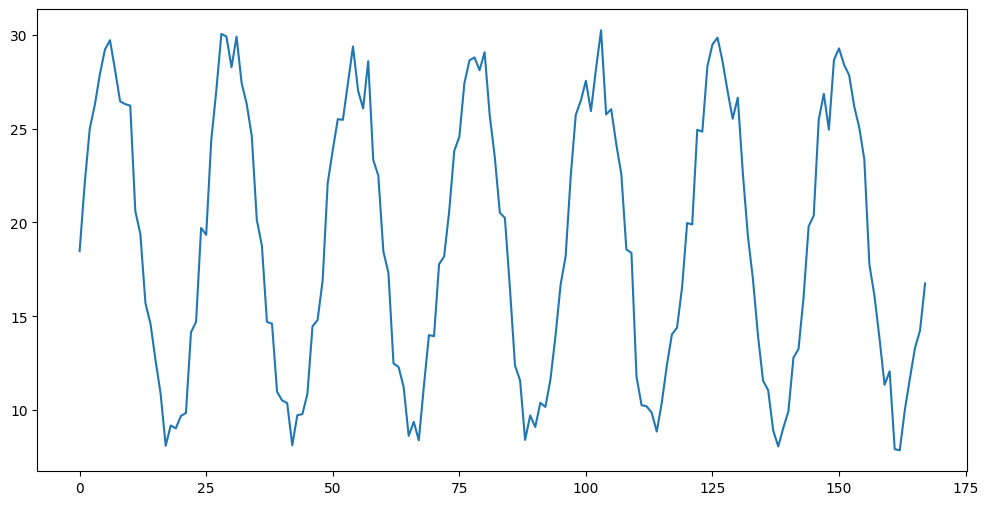

In [50]:
plt.figure(figsize=(12,6))
plt.plot(temperature)  
plt.show()

In [51]:
temp_data = np.array(temperature.copy())
missing_indices = np.random.choice(len(temp_data), size=10, replace=False)
temp_data[missing_indices] = np.nan

In [52]:
temp_data[5] = 50    # مقدار بسیار بالا
temp_data[100] = 5   # مقدار بسیار پایین


In [53]:
df = pd.DataFrame({'timestamp': date_rng, 'temperature': temp_data})
df.set_index('timestamp', inplace=True)


In [55]:
df.head(100)

,temperature
timestamp,
2025-03-01 00:00:00,18.471449
2025-03-01 01:00:00,22.057564
2025-03-01 02:00:00,24.990548
2025-03-01 03:00:00,26.254081
2025-03-01 04:00:00,27.890628
...,...
2025-03-04 23:00:00,16.669260
2025-03-05 00:00:00,18.193959
2025-03-05 01:00:00,22.432963


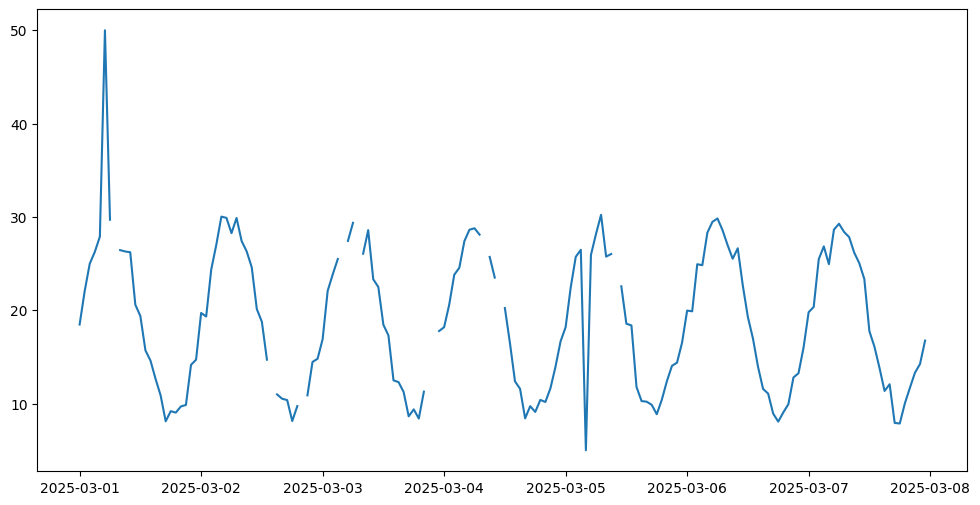

In [56]:
plt.figure(figsize=(12,6))
plt.plot(df['temperature'])  
plt.show()

In [57]:
df['temperature'] = df['temperature'].fillna(method='ffill')


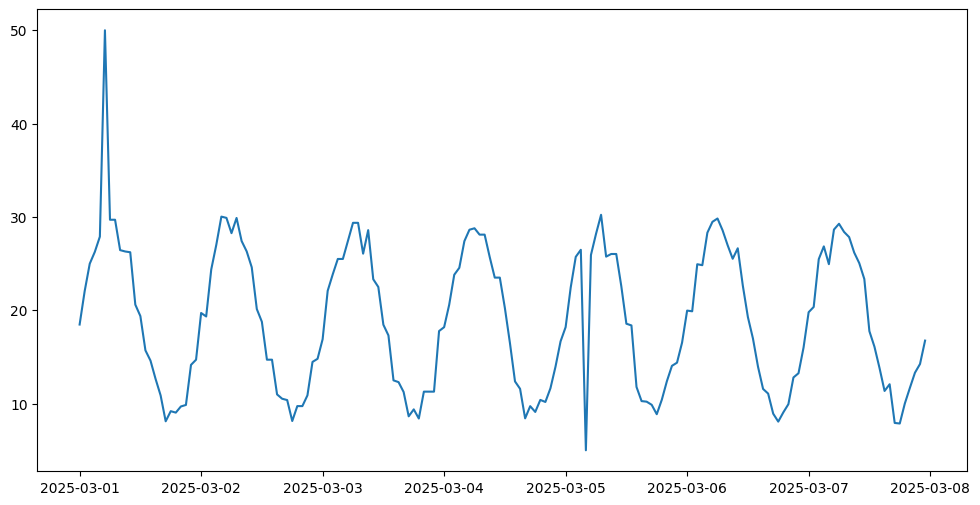

In [58]:
plt.figure(figsize=(12,6))
plt.plot(df['temperature'])  
plt.show()

In [76]:
Q1 = df['temperature'].quantile(0.25)
Q3 = df['temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = 10
upper_bound = Q3 + 1.5 * IQR
df_clean = df[(df['temperature'] >= lower_bound) & (df['temperature'] <= upper_bound)]

In [75]:
upper_bound

47.43611251755999

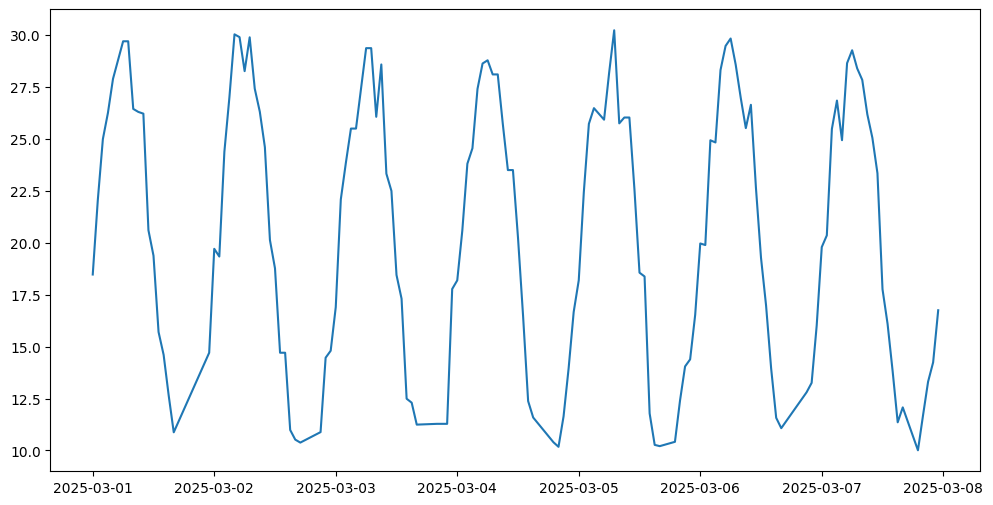

In [77]:
plt.figure(figsize=(12,6))
plt.plot(df_clean['temperature'])  
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10096\2979044688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['hour'] = df_clean.index.hour
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10096\2979044688.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['dayofweek'] = df_clean.index.dayofweek
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10096\2979044688.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

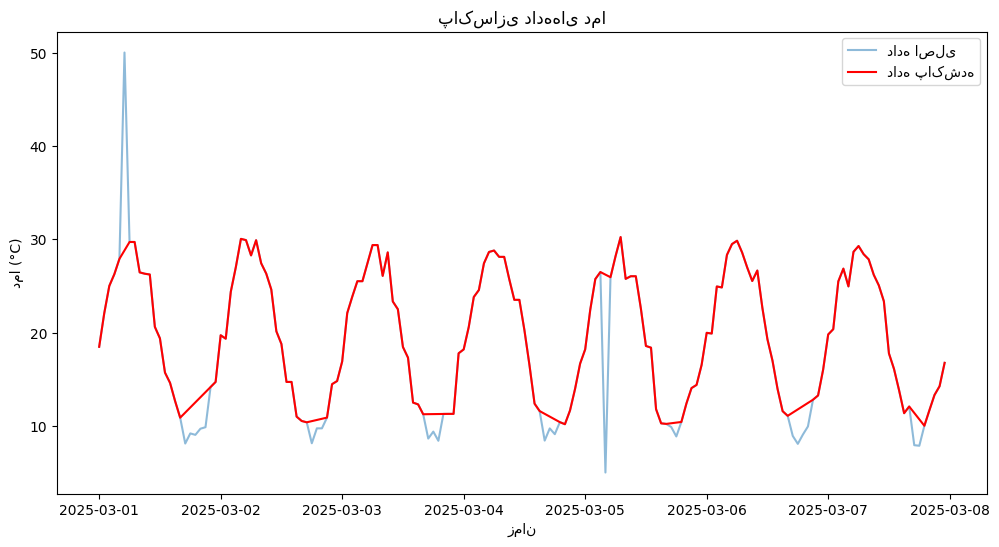

In [79]:
df_clean['hour'] = df_clean.index.hour
df_clean['dayofweek'] = df_clean.index.dayofweek

# برچسب‌گذاری: اگر دما بالاتر از 28 درجه باشد، برچسب "High" و در غیر این صورت "Normal"
df_clean['label'] = df_clean['temperature'].apply(lambda x: 'High' if x > 28 else 'Normal')

# ----------------- مرحله ۴: تحلیل و نمایش داده‌ها -----------------
plt.figure(figsize=(12,6))
plt.plot(df.index, df['temperature'], label='داده اصلی', alpha=0.5)
plt.plot(df_clean.index, df_clean['temperature'], label='داده پاک‌شده', color='red')
plt.title('پاک‌سازی داده‌های دما')
plt.xlabel('زمان')
plt.ylabel('دما (°C)')
plt.legend()
plt.show()

In [80]:
features = df_clean[['hour', 'dayofweek']]
target = df_clean['temperature']

# تقسیم داده به مجموعه‌های آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# آموزش مدل رگرسیون خطی
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ارزیابی مدل
mse = mean_squared_error(y_test, y_pred)
print(f"خطای میانگین مربعات (MSE): {mse:.2f}")

# ----------------- مرحله ۶: ذخیره‌سازی دیتاست نهایی -----------------
df_clean.reset_index(inplace=True)
df_clean.to_csv("dataset1.csv", index=False)
print("دیتاست نهایی در فایل 'sensor_temperature_dataset.csv' ذخیره شد.")

خطای میانگین مربعات (MSE): 19.79
دیتاست نهایی در فایل 'sensor_temperature_dataset.csv' ذخیره شد.


In [81]:
y_pred  


array([17.67184026, 27.13508206, 26.92013325, 14.96038015, 14.18847502,
       19.10817612, 21.04773111, 24.20867314, 23.54424241, 27.79951279,
       19.50392084, 13.57778149, 18.28253379, 20.38330038, 12.96708796,
       24.87310387, 21.81963624, 21.55095023, 25.6987462 , 18.89322732,
       19.77260685, 13.68525589, 22.32285536, 20.32956318, 16.84619793,
       23.49050521, 21.10146831, 25.08805268, 22.48406697, 26.36317693,
       19.16191332, 14.29594942, 13.8464675 , 13.12829957, 20.43703758,
       18.94696452, 21.65842463, 25.48379739, 17.00740953, 24.36988475,
       16.95367233, 27.53082678, 27.74577559, 25.5912718 ])

In [82]:
y_test

timestamp
2025-03-06 15:00:00    11.572802
2025-03-02 01:00:00    19.337301
2025-03-05 01:00:00    22.432963
2025-03-05 19:00:00    10.416772
2025-03-03 20:00:00    11.282226
2025-03-01 13:00:00    15.703446
2025-03-07 10:00:00    25.050782
2025-03-04 05:00:00    28.630225
2025-03-04 06:00:00    28.785743
2025-03-02 00:00:00    19.708868
2025-03-03 12:00:00    18.450475
2025-03-04 21:00:00    11.643273
2025-03-05 14:00:00    11.785757
2025-03-07 11:00:00    23.346706
2025-03-05 22:00:00    14.386166
2025-03-04 04:00:00    27.407134
2025-03-02 09:00:00    26.308708
2025-03-04 09:00:00    25.716549
2025-03-07 03:00:00    26.845421
2025-03-04 13:00:00    16.486602
2025-03-01 12:00:00    19.377696
2025-03-06 21:00:00    12.799840
2025-03-06 08:00:00    26.972076
2025-03-06 11:00:00    22.641862
2025-03-03 16:00:00    11.244715
2025-03-03 06:00:00    29.369612
2025-03-01 10:00:00    26.216104
2025-03-01 04:00:00    27.890628
2025-03-02 08:00:00    27.419912
2025-03-07 02:00:00    25.479052


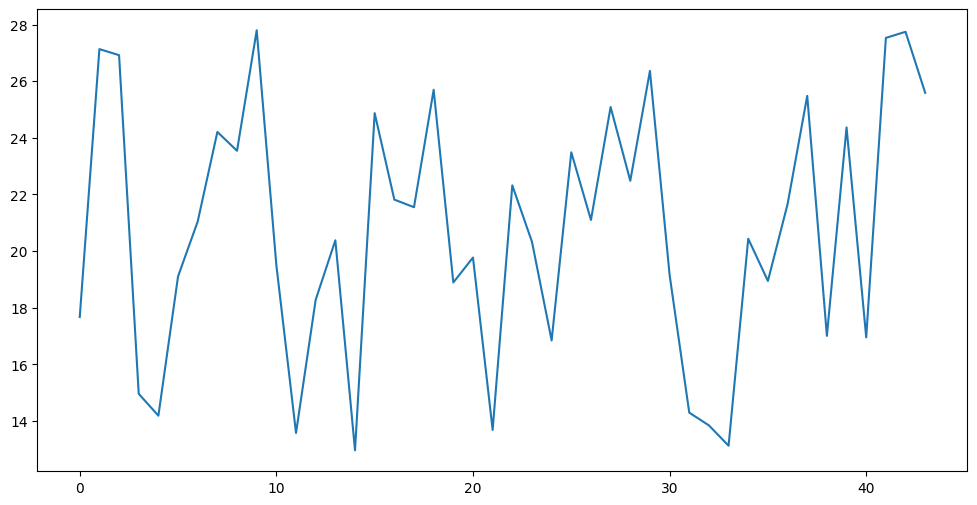

In [84]:
plt.figure(figsize=(12,6))
plt.plot(y_pred)  
plt.show()